# 06 · Extending and shipping

Every program so far used operations, waveforms, and sweep sources that ship with QProgram. Real labs run out of those on day one: a pulse shape the vendor's compiler already knows and the DSL does not, a room-temperature attenuator that no core operation will ever cover, a chevron scanned by centre and span instead of start and stop.

QProgram answers all three the same way. You write a class, you make one registration call, and the serializer, the parser, the validator, and the plotting layer pick it up with no change to the core.

- register a **waveform**, a **sweep source**, and a **vendor namespace**, live in this notebook
- watch the `require` line appear in the `.qp` text, and a rack that lacks the token refuse the program
- diff two calibration runs and run the checker from a shell
- run the whole bring-up as one capstone, a file per step and a calibration summary against the true device values

In [1]:
# Run me first. A no-op when qprogram is already installed, an install when it is not
# (a fresh Google Colab runtime, for example).
# Section 6.2 loads a file that requires the qblox vendor, and the point of that cell is the import
# happening on demand, so probe for the distributions rather than importing them here.
from importlib.util import find_spec

if find_spec("qprogram") is None or find_spec("qprogram_qblox") is None:
    import subprocess
    import sys

    subprocess.run(
        [
            sys.executable, "-m", "pip", "install",
            "qprogram[viz]==0.1.0", "qprogram-qblox==0.1.0", "qprogram-qdac==0.1.0", "scipy",
        ],
        check=True,
    )

from importlib.metadata import version

print("qprogram", version("qprogram"))
print("qprogram-qblox", version("qprogram-qblox"), "· qprogram-qdac", version("qprogram-qdac"))

qprogram 0.1.0
qprogram-qblox 0.1.0 · qprogram-qdac 0.1.0


In [2]:
import difflib
import json
import subprocess
import sys
import tempfile
from dataclasses import replace
from importlib.metadata import entry_points
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

import qprogram as qp
from qprogram import MeasurementField as MF
from qprogram.buses import BusSchema
from qprogram.operations.operation import Operation
from qprogram.plotting import LIGHT, Quantity, Style
from qprogram.waveforms import IQDrag, IQPair, Square, Waveform

print("imports ready")

imports ready


## 6.0 What we carry in

The capstone runs the whole bring-up, so the six cells below collect what the earlier parts built: the device truth, the response models that stand in for the fridge, the pulse sequences from Part 4, and the helpers that turn one sweep and one fit into two lines. It is short because they exist.

The schema is the flux-tunable one this time, because the custom waveform in 6.1 is a flux pulse and a flux pulse needs a single-channel bus to live on.

In [3]:
DEVICE = {
    "q0_f01": 4.85e9,  # Hz, at the flux sweet spot
    "q0_fr": 7.20e9,  # Hz, readout resonator
    "q0_kappa": 1.5e6,  # Hz, resonator linewidth (FWHM)
    "q0_a_pi": 0.62,  # drive amplitude of a pi pulse (DAC units)
    "q0_T1": 18_000,  # ns
    "q0_T2star": 9_000,  # ns
    "q0_T2echo": 16_000,  # ns
    "q0_linewidth": 2.0e6,  # Hz, spectroscopy FWHM at low power
    "cz_g": 6.0e6,  # Hz, coupling to the neighbour
    "cz_amp_res": 0.42,  # flux amplitude that brings the pair into resonance
    "cz_slope": 1.2e9,  # Hz per unit flux amplitude
}
DETUNING = 0.5e6  # Hz, the detuning we put into the Ramsey on purpose
P_HOT = 0.22  # residual excited-state population before reset

schema = BusSchema.flux_tunable_transmon()
q = schema.q
PI = IQDrag(amplitude=DEVICE["q0_a_pi"], duration=40, sigma=10, beta=0.1)
X90 = IQDrag(amplitude=DEVICE["q0_a_pi"] / 2, duration=40, sigma=10, beta=0.1)
# Seed carriers. Steps 1 and 2 of the capstone measure both and rebind them, the same way
# steps 3 replaces the seed pulses above.
RO_FREQ = DEVICE["q0_fr"]
DRIVE_FREQ = DEVICE["q0_f01"]

print("buses on this chip:", [q[0].drive, q[0].readout, q[0].flux])
print(f"pi pulse: IQDrag amplitude {PI.amplitude}, duration {PI.duration} ns")
print(f"pi/2 pulse: IQDrag amplitude {X90.amplitude}, duration {X90.duration} ns")

buses on this chip: ['q0/drive', 'q0/readout', 'q0/flux']
pi pulse: IQDrag amplitude 0.62, duration 40 ns
pi/2 pulse: IQDrag amplitude 0.31, duration 40 ns


The response models are the ones from Parts 2 to 4, unchanged. Each is a plain function of `env`, the dict of loop variables currently bound. None is physics from first principles, and each produces the shape a real scan produces, so the programs and the fits are the real part.

Active reset needs something a `response` function cannot express, because the second measurement of a shot depends on what the first one saw. A `MeasurementModel` is any object with a `sample(bus, env)` method, called once per shot per measurement in program order, so a model is free to remember. A model that simulates an ADC also declares `raw_samples` and fills in the sample's `raw` trace; the models here leave both out.

A model cannot watch the executor, so it never learns which branch of a conditional ran. `ResetModel` assumes the program plays a pi pulse when the check reads 1, and the capstone program does exactly that.

In [4]:
def s21(bus, env):
    """Resonator transmission: a dip at f_r, kappa wide."""
    detuning = (env["ro_freq"] - DEVICE["q0_fr"]) / (DEVICE["q0_kappa"] / 2)
    return 1.0 - 0.9 / (1.0 + 1j * detuning)


def p_spec(bus, env):
    """Qubit spectroscopy: excited-state population, a Lorentzian peak at f01."""
    hwhm = DEVICE["q0_linewidth"] / 2
    return 0.45 / (1.0 + ((env["drive_freq"] - DEVICE["q0_f01"]) / hwhm) ** 2)


def p_rabi(bus, env):
    return np.sin(np.pi * env["amp"] / (2 * DEVICE["q0_a_pi"])) ** 2


def p_t1(bus, env):
    return np.exp(-env["delay"] / DEVICE["q0_T1"])


def p_ramsey(bus, env):
    t = env["delay"]
    return 0.5 * (1.0 + np.cos(2 * np.pi * DETUNING * t * 1e-9)) * np.exp(-t / DEVICE["q0_T2star"])


def p_echo(bus, env):
    return 0.5 + 0.5 * np.exp(-env["delay"] / DEVICE["q0_T2echo"])


print("p_rabi at the pi amplitude:", round(p_rabi(None, {"amp": DEVICE["q0_a_pi"]}), 4))
print("p_t1 after one T1:", round(p_t1(None, {"delay": DEVICE["q0_T1"]}), 4))

p_rabi at the pi amplitude: 1.0
p_t1 after one T1: 0.3679


In [5]:
class ResetModel:
    """Two measurements per shot: the check, then the verify, which remembers the check."""

    def __init__(self, p_hot, fidelity=0.97, seed=17):
        self.p_hot, self.fidelity = p_hot, fidelity
        self.rng = np.random.default_rng(seed)
        self.pending = None

    def sample(self, bus, env):
        if self.pending is None:  # the check
            state = int(self.rng.random() < self.p_hot)
            self.pending = state
        else:  # the verify: a hot qubit got the pi pulse, a cold one was left alone
            was, self.pending = self.pending, None
            state = int(self.rng.random() > self.fidelity) if was else int(self.rng.random() < 0.01)
        return qp.MeasurementSample(i=1.0 if state else -1.0, q=0.0, state=state)


peek = ResetModel(p_hot=0.5)  # a hot qubit, so the pattern shows up in six shots
pairs = [(peek.sample(q[0].readout, {}).state, peek.sample(q[0].readout, {}).state) for _ in range(6)]
print("(check, verify) per shot:", pairs)

(check, verify) per shot: [(0, 0), (0, 0), (1, 0), (1, 0), (0, 0), (1, 0)]


Every experiment in the bring-up has the same skeleton: average, sweep one variable, do something, measure. `sweep_program` writes that skeleton and hands back the program and the measurement handle.

It also declares the swept variable with a `label` and `units`. Both strings travel onto the xarray coordinate the executor builds, and `result.plot` reads them back off it, so a figure comes out with `Delay (ns)` under the x axis and nobody typed it. `AXES` holds the pair per variable, plus the unit the figure wants when it differs from the unit the instrument takes, because a delay is programmed in nanoseconds and read in microseconds. `OUT` is where the capstone drops its files.

In [6]:
OUT = Path("out/bringup")
OUT.mkdir(parents=True, exist_ok=True)

# variable id -> (axis label, the unit the program uses, the unit the figure wants, the divisor).
AXES = {
    "ro_freq": ("Readout frequency", "Hz", "GHz", 1e9),
    "drive_freq": ("Drive frequency", "Hz", "GHz", 1e9),
    "amp": ("Drive amplitude", "DAC units", None, 1.0),
    "delay": ("Delay", "ns", "us", 1000.0),
}
UNLABELED = (None, None, None, 1.0)


def sweep_program(name, var, source, middle, *, shots, fields):
    """average -> sweep(var) -> middle(program, var) -> measure, the shape of every scan here."""
    label, units, _, _ = AXES.get(var, UNLABELED)
    program = qp.QProgram(label=name, schema=schema)
    swept = program.variable(var, label=label, units=units)
    with program.average(shots=shots):
        with program.sweep(swept, source):
            middle(program, swept)
            handle = program.measure(q[0].readout, "readout", "weights", fields=fields)
    return program, handle


def restated(var):
    """The `coords=` entry that redraws one axis in the unit the figure wants, or None when it matches."""
    _, _, figure_units, scale = AXES.get(var, UNLABELED)
    if figure_units is None:
        return None
    return {var: Quantity(units=figure_units, transform=lambda values: values / scale)}


def magnitude(data):
    """|S21| from a `(..., IQ)` DataArray."""
    return np.abs(data.sel(IQ="I").values + 1j * data.sel(IQ="Q").values)


demo, _ = sweep_program(
    "smoke_test",
    "amp",
    qp.Linspace(0.0, 1.0, 3),
    lambda program, amp: program.play(q[0].drive, IQDrag(amp, 40, 10, 0.1)),
    shots=10,
    fields=(MF.STATE,),
)
print(qp.dumps(demo))

#!QProgram 1.0

metadata:
  label: "smoke_test"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires
    flux info=single

body:
  var amp label="Drive amplitude" units="DAC units"

  average 10:
    for amp in Linspace(start=0.0, stop=1.0, num=3):
      play q[0].drive IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1)
      measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]



In [7]:
# The middles of the four experiments that need one: ordinary functions of the program and the swept
# variable, which is all `sweep_program` asks for.
def spec_tone(program, freq):
    program.set_frequency(q[0].readout, RO_FREQ)  # step 1 measured this
    program.set_frequency(q[0].drive, freq)
    program.play(q[0].drive, IQPair(Square(0.05, 2000), Square(0.0, 2000)))
    program.sync()


def t1_pulses(program, delay):
    program.set_frequency(q[0].readout, RO_FREQ)
    program.set_frequency(q[0].drive, DRIVE_FREQ)  # step 2 measured this
    program.play(q[0].drive, PI)
    program.wait(q[0].drive, delay)
    program.sync()


def ramsey_pulses(program, delay):
    program.set_frequency(q[0].readout, RO_FREQ)
    program.set_frequency(q[0].drive, DRIVE_FREQ + DETUNING)  # off resonance on purpose
    program.play(q[0].drive, X90)
    program.wait(q[0].drive, delay)
    program.play(q[0].drive, X90)
    program.sync()


def echo_pulses(program, delay):
    program.set_frequency(q[0].readout, RO_FREQ)
    program.set_frequency(q[0].drive, DRIVE_FREQ)  # on resonance, the pi pulse does the refocusing
    program.play(q[0].drive, X90)
    program.wait(q[0].drive, delay / 2)
    program.play(q[0].drive, PI)  # the pi pulse that refocuses the detuning
    program.wait(q[0].drive, delay / 2)
    program.play(q[0].drive, X90)
    program.sync()


demo, _ = sweep_program("echo", "delay", qp.Range(0, 2000, 1000), echo_pulses, shots=1, fields=(MF.STATE,))
print("body:" + qp.dumps(demo).split("body:", 1)[1].rstrip())

body:
  var delay label="Delay" units="ns"

  average 1:
    for delay in Range(start=0.0, stop=2000.0, step=1000.0):
      set_frequency q[0].readout 7200000000.0
      set_frequency q[0].drive 4850000000.0
      play q[0].drive IQDrag(amplitude=0.31, duration=40, sigma=10, beta=0.1)
      wait q[0].drive (delay / 2)
      play q[0].drive IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.1)
      wait q[0].drive (delay / 2)
      play q[0].drive IQDrag(amplitude=0.31, duration=40, sigma=10, beta=0.1)
      sync
      measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]


The fits are one line each. `step` puts the pieces together: build the program, save the `.qp` file, run it, fit, and keep the result object so the capstone can draw all six sweeps at once.

Keeping the result rather than a pair of arrays keeps `draw` short. It hands the drawing back to `result.plot`, which already knows which dimension is the sweep and what the variable was called, and `restated` says what unit to read it in. The fit goes over the top as an ordinary matplotlib call on the axes that comes back, so the delays divide by the same 1000 the axis did.

In [8]:
def dip(f, f0, width, depth, base):
    return base - depth / (1.0 + ((f - f0) / (width / 2)) ** 2)


def peak(f, f0, hwhm, height, base):
    return base + height / (1.0 + ((f - f0) / hwhm) ** 2)


def rabi(a, a_pi):
    return np.sin(np.pi * a / (2 * a_pi)) ** 2


def decay(t, tau):
    return np.exp(-t / tau)


def fringe(t, t2, det):
    return 0.5 * (1.0 + np.cos(2 * np.pi * det * t * 1e-9)) * np.exp(-t / t2)


def half_decay(t, tau):
    return 0.5 + 0.5 * np.exp(-t / tau)


TRACES = {}


def step(name, var, source, middle, model, curve, p0, *, shots=200, field=MF.STATE,
         channels=None, measured="Excited population"):
    """Run one bring-up step, save it as `<name>.qp`, fit `curve`, and return the fitted values."""
    program, handle = sweep_program(name, var, source, middle, shots=shots, fields=(field,))
    qp.save(program, OUT / f"{name}.qp")
    result = qp.simulate(program, model=model)
    data = result.get(handle, field=field)
    x = data.coords[var].values
    y = data.values if field is MF.STATE else magnitude(data)
    popt, _ = curve_fit(curve, x, y, p0=p0, maxfev=40000)
    TRACES[name] = {
        "result": result, "handle": handle, "field": field, "var": var,
        "channels": channels, "measured": measured, "x": x, "curve": curve, "popt": popt,
    }
    return popt


def draw(name, target=None):
    """Draw one step the way its result draws itself, with the fitted curve over the top."""
    trace = TRACES[name]
    ax = trace["result"].plot(
        trace["handle"], field=trace["field"], channels=trace["channels"], target=target,
        coords=restated(trace["var"]), value=Quantity(trace["measured"]),
        style=Style(markers=True, linewidth=0.8, legend=False),
    )
    scale = AXES.get(trace["var"], UNLABELED)[3]
    ax.plot(trace["x"] / scale, trace["curve"](trace["x"], *trace["popt"]),
            lw=1.5, color=LIGHT.series[1], label="fit")
    ax.lines[0].set_label("measured")
    return ax


print("rabi shape at a_pi/2 and a_pi:", rabi(np.array([0.31, 0.62]), 0.62).round(3))
print("decay shape after one tau:", round(float(decay(np.array([1.0]), 1.0)[0]), 3))

rabi shape at a_pi/2 and a_pi: [0.5 1. ]
decay shape after one tau: 0.368


## 6.1 Three extension points

QProgram has three seams for new vocabulary, and they are orthogonal. Nothing in the core knows any vendor's name.

| You want | You write | You get for free |
|---|---|---|
| a pulse shape the DSL lacks | a `Waveform` subclass, `@qp.register_waveform` | `.qp` serialization from the constructor signature, structural equality, validation, plotting |
| a sweep axis the DSL lacks | a `SweepSource` subclass, `@qp.register_sweep_source` | serialization, a capability token, lockstep length checks, xarray coordinates |
| an operation the DSL will never have | an `Operation` plus a `VendorNamespace`, four registration calls | `program.<vendor>.<op>(...)`, a `require` line, a `vendor.<name>.<op>` token |

The right-hand column costs one constraint. Serialization is derived by reading your `__init__` signature, so the constructor arguments have to *be* the object's state. Store a parameter under a different attribute name, or compute state the constructor cannot reproduce, and the round trip breaks with no warning.

A fourth seam this notebook does not need: `qp.register_vendor_block` adds a block keyword with its own indented suite, for a vendor that ships control flow of its own.

Registration is global and keyed by class name, so each of the three registration cells below runs once. Re-running one raises a collision error, and editing a class means restarting the kernel.

### A custom waveform

Flux-activated two-qubit gates want a pulse that starts and ends at zero. The reason is the line rather than the gate. A flux line through a fridge is a filter with long time constants, so a step left at the end of a pulse comes back as a slow tail, and the next gate runs on a chip the previous gate detuned.

A half sine is zero at both endpoints and takes one parameter. Its slope there is not zero, so it is continuous but not smooth, and labs chasing the last percent reach for a raised cosine. The DSL has a name for neither shape, though a vendor's compiler may well emit the half sine natively.

A `Waveform` owes two methods. `envelope(resolution)` returns the samples and `get_duration()` returns the length in nanoseconds. `@qp.register_waveform` puts the class in the serialization registry under its own name, and `qp.register_waveform_token` gives it a capability token, so a platform gets to say whether it supports the shape.

### Sweeping a waveform parameter

A parameter you intend to sweep is annotated `float | qp.Expression` and resolved with `evaluate_or_raise()` at the point of use. The program later in this section puts a swept variable in the amplitude position, and a bare multiplication would meet a `Variable` instead of a number. Every shape the core ships is written this way. Skip it and nothing complains until a real platform calls `envelope()`, and then it fails inside numpy with a message that names neither the waveform nor the variable.

### What the base class provides

Read the next cell for what it does not contain. `HalfSine.plot()` appears nowhere in it, and neither do `area()`, `peak_amplitude()`, `spectrum()`, nor the Jupyter repr that draws the envelope when a bare `HalfSine(0.42, 40)` is the last line of a cell. All of it comes from `Waveform`, drawn through the same figure model and the same palette as every result here, so a pulse and the sweep it produced look like one experiment. Putting the core's `Square` beside it is a `target=` and a rotated palette.

written on HalfSine: ['envelope', 'get_duration']
inherited from Waveform: ['plot', 'area', 'peak_amplitude', 'rms_amplitude', 'spectrum']
area 10.673, peak amplitude 0.420


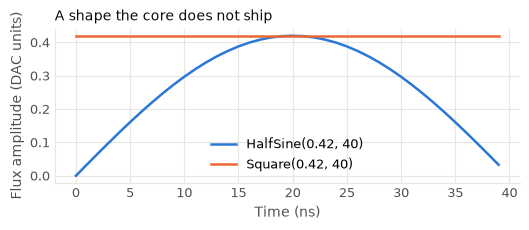

In [9]:
@qp.register_waveform
class HalfSine(Waveform):
    """A single half period of a sine: zero at both ends, no ringing on the flux line."""

    def __init__(self, amplitude: float | qp.Expression, duration: int) -> None:
        self.amplitude, self.duration = amplitude, duration

    def envelope(self, resolution: int = 1) -> np.ndarray:
        amplitude = self.amplitude
        if isinstance(amplitude, qp.Expression):  # bound by the sweep this pulse sits in
            amplitude = amplitude.evaluate_or_raise()
        n = self.duration // resolution
        return amplitude * np.sin(np.pi * np.arange(n) / n)

    def get_duration(self) -> int:
        return self.duration


qp.register_waveform_token(HalfSine, "waveform.half_sine")

flux_pulse = HalfSine(amplitude=0.42, duration=40)
ax = flux_pulse.plot()
rotated = Style(theme=replace(LIGHT, series=LIGHT.series[1:] + LIGHT.series[:1]))
Square(amplitude=0.42, duration=40).plot(target=ax, style=rotated)
for line, name in zip(ax.lines, ("HalfSine(0.42, 40)", "Square(0.42, 40)"), strict=True):
    line.set_label(name)
ax.set_title("A shape the core does not ship", loc="left", fontsize=10)
ax.set_ylabel("Flux amplitude (DAC units)")
ax.legend(frameon=False, fontsize=9)

print("written on HalfSine:", sorted(name for name in vars(HalfSine) if not name.startswith("_")))
print("inherited from Waveform:",
      [name for name in ("plot", "area", "peak_amplitude", "rms_amplitude", "spectrum")
       if name not in vars(HalfSine)])
print(f"area {flux_pulse.area():.3f}, peak amplitude {flux_pulse.peak_amplitude():.3f}")

### A custom sweep source

A chevron scan is always written the same way in a lab notebook: a centre, a span, and how many points. `Range` and `Linspace` want endpoints, so every script grows the same two lines of arithmetic. A sweep source removes them.

The contract is three declarations, and each has a real consumer:

- `length()` is static. A parallel loop checks it before anything runs, and the executor sizes the result array with it.
- `KIND` is `"linear"` or `"arbitrary"`, a claim about compilability. A sequencer generates a linear ramp in hardware, and everything else is uploaded as a table.
- `values()` produces the numbers, for the interpreter, for the xarray coordinate, and for `optimize()`.

All three have to be answerable before the sweep runs, and that is why a source cannot wrap a callable. `Chevron` computes its values from three stored numbers, so the length check, the honest `KIND`, and the round trip through text all fall out of the class below.

In [10]:
@qp.register_sweep_source
class Chevron(qp.SweepSource):
    """A symmetric scan around a centre, the way a chevron gets written on a whiteboard."""

    KIND = "arbitrary"
    TOKEN = "sweep.chevron"

    def __init__(self, center: float, span: float, num: int) -> None:
        self.center, self.span, self.num = center, span, num

    def length(self) -> int:
        return self.num

    def values(self):
        return np.linspace(self.center - self.span / 2, self.center + self.span / 2, self.num)


scan = Chevron(center=0.42, span=0.20, num=21)
print("length:", scan.length(), " kind:", scan.KIND)
print("tokens it asks a platform for:", sorted(scan.tokens()))
print("first three values:", scan.values()[:3].round(3))
# A combinator unions its child's tokens with its own, so a platform missing `sweep.chevron`
# refuses the rotation too.
print("wrapped in Rotate:", sorted(qp.Rotate(scan, 5).tokens()))

length: 21  kind: arbitrary
tokens it asks a platform for: ['sweep.arbitrary', 'sweep.chevron']
first three values: [0.32 0.33 0.34]
wrapped in Rotate: ['sweep.arbitrary', 'sweep.chevron', 'sweep.rotate']


### A vendor namespace

The two seams above add vocabulary the core could plausibly have shipped. The third is for things the core must never ship. Our fridge has a programmable room-temperature attenuator on the drive line, one box in one rack, and `op.set_attenuation` has no business in a vendor-agnostic DSL.

Four calls put it in the language anyway:

1. `QProgram.register_vendor` makes `program.fridge` resolve at runtime, on any `QProgram`.
2. `register_vendor_version` fixes the version that goes into the `require` line.
3. `register_vendor_operation` teaches the writer and the parser about the operation. The default parser reads your `__init__` signature.
4. `register_capability_tokens` puts the token in the registry, so a platform can say yes or no to it.

A shipped extension makes all four calls in its package `__init__.py`, and publishes a profile besides. A token says an operation exists; a profile is the named and versioned bundle a rack points at to say which tokens it has. Importing the package is the activation step for all of it.

In [11]:
class SetAttenuation(Operation):
    """Set the room-temperature attenuator on a drive line, in dB."""

    def __init__(self, bus: str, db: float) -> None:
        self.bus, self.db = bus, db

    def required_capabilities(self) -> set[str]:
        return {"vendor.fridge.set_attenuation"}


class FridgeNamespace(qp.VendorNamespace):
    def set_attenuation(self, bus: str, db: float) -> None:
        self._append(SetAttenuation(bus=bus, db=db))


qp.QProgram.register_vendor("fridge", FridgeNamespace)
qp.register_vendor_version("fridge", "0.1.0")
qp.register_vendor_operation("fridge", "set_attenuation", SetAttenuation)
qp.register_capability_tokens("vendor.fridge.set_attenuation")

# `_vendor_registry` is private and there is no public accessor for it yet. Reading it here is a
# look behind the curtain, not an API to build on.
print("vendor namespaces registered:", sorted(qp.QProgram._vendor_registry))
print("SetAttenuation asks for:", SetAttenuation(q[0].drive, 20.0).required_capabilities())

vendor namespaces registered: ['fridge']
SetAttenuation asks for: {'vendor.fridge.set_attenuation'}


### A flux-activated swap

Two qubits at different frequencies barely interact. Push one with a flux pulse until it lands on the other and the pair exchanges excitations at a rate set by their coupling $g$. Sweep the flux amplitude around resonance and the swap probability after a fixed pulse follows the detuned Rabi formula,

$$P_{\text{swap}} = \frac{(2g)^2}{\Omega^2}\sin^2(\pi \Omega t), \qquad \Omega = \sqrt{(2g)^2 + \Delta^2}$$

with $\Delta$ the residual detuning, proportional to how far the flux amplitude sits from resonance. On resonance the prefactor is 1 and the pair swaps completely. Off resonance the oscillation goes faster and reaches less far, the pattern that gives a chevron its name once you add the duration axis. The amplitude at the peak is the number the scan exists to find.

### All three in one program

The program attenuates the drive line, then steps the flux amplitude and reads the qubit out. The custom waveform, the custom sweep source, and the vendor operation all appear in the `.qp` text, and the file grew a `require fridge 0.1` line under the header. That line is the contract. A lab without the extension installed gets a `ParseError` naming the vendor it is missing, instead of a file that loads with an operation silently dropped.

The file also round-trips. The parser rebuilds `HalfSine`, `Chevron`, and `fridge.set_attenuation` from the text with no help from you, because each is registered under its class name and serialized from its constructor signature. The reference platform accepts every token in the registry, so the program validates and runs.

The figure is one call. `flux_amp` was declared with a label and a unit, so the axis reads `Flux amplitude (DAC units)`, and the positions along it are the numbers `Chevron.values()` produced. The dashed line is where the model put the resonance.

#!QProgram 1.0

require fridge 0.1

metadata:
  label: "cz_chevron"
  description: "flux-activated swap on the fridge rack"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires
    flux info=single

body:
  var flux_amp label="Flux amplitude" units="DAC units"

  fridge.set_attenuation q[0].drive 20.0
  average 200:
    for flux_amp in Chevron(center=0.42, span=0.2, num=21):
      play q[0].flux HalfSine(amplitude=flux_amp, duration=40)
      sync
      measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]



round-trips: True
diagnostics from the reference platform: []


swap peaks at 0.420, resonance is at 0.420


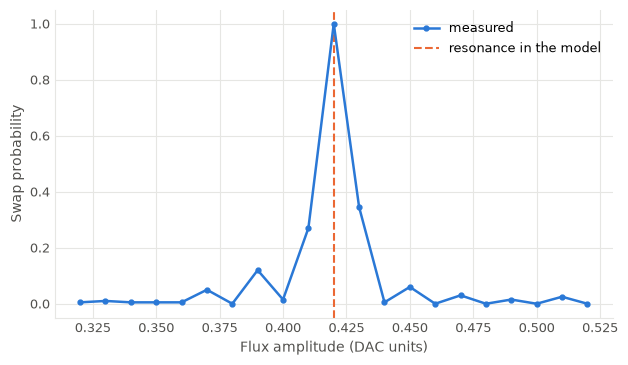

In [12]:
program = qp.QProgram(label="cz_chevron", description="flux-activated swap on the fridge rack", schema=schema)
flux_amp = program.variable("flux_amp", label="Flux amplitude", units="DAC units")

program.fridge.set_attenuation(q[0].drive, 20.0)
with program.average(shots=200):
    with program.sweep(flux_amp, Chevron(center=0.42, span=0.20, num=21)):
        program.play(q[0].flux, HalfSine(amplitude=flux_amp, duration=40))
        program.sync()
        swap = program.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))

text = qp.dumps(program)
print(text)
print("round-trips:", qp.loads(text).body == program.body)
print("diagnostics from the reference platform:", qp.validate(program, qp.reference_capabilities())[0])


def p_swap(bus, env):
    """Swap probability after a 40 ns half-sine flux pulse of the given amplitude."""
    delta = (env["flux_amp"] - DEVICE["cz_amp_res"]) * DEVICE["cz_slope"]
    omega = np.sqrt((2 * DEVICE["cz_g"]) ** 2 + delta**2)
    contrast = (2 * DEVICE["cz_g"]) ** 2 / omega**2
    return contrast * np.sin(np.pi * omega * 40 * 1e-9) ** 2


chevron_run = qp.simulate(program, model=qp.MockMeasurementModel(p_excited=p_swap, seed=21))
data = chevron_run.get(swap, field=MF.STATE)
amps = data.coords["flux_amp"].values

ax = chevron_run.plot(swap, field=MF.STATE, value=Quantity("Swap probability"), style=Style(markers=True))
ax.lines[0].set_label("measured")
ax.axvline(DEVICE["cz_amp_res"], linestyle="--", color=LIGHT.series[1], label="resonance in the model")
ax.legend(frameon=False, fontsize=9)

print(f"swap peaks at {amps[data.values.argmax()]:.3f}, resonance is at {DEVICE['cz_amp_res']:.3f}")

### A rack without the token

Registering a token does not mean every rack has the box. Build a platform descriptor that knows everything except our attenuator, and the validator names what is missing and where it sits in the program, before anything is uploaded and while the file is still legal QProgram everywhere else.

In [13]:
from qprogram.protocol import CAPABILITY_REGISTRY

no_fridge = frozenset(CAPABILITY_REGISTRY) - {"vendor.fridge.set_attenuation"}
profile = qp.CompilerCapabilities(
    profile="no-fridge", version=(0, 1, 0), capabilities=no_fridge, limits={}, predicates=(), vendor_versions={}
)
plain_rack = qp.BusCapabilities(rt=profile, host=profile)
caps = qp.PlatformCapabilities(bus={}, platform=plain_rack, default_bus_profile=plain_rack)

for d in qp.validate(program, caps)[0]:
    print(f"[{d.severity}] {d.code}: {d.message}")
    print("  at path:", qp.format_path(d.path))
print()
print(qp.explain(program, caps))

[error] missing-capability: 'SetAttenuation' requires capability 'vendor.fridge.set_attenuation' which is not supported by 'no-fridge' (rt) / 'no-fridge' (host)
  at path: body[0]

plan for 'cz_chevron' — errors: 1 · warnings: 0 · info: 0
body
├─ fridge.set_attenuation q[0].drive 20.0                                                [--]       !! missing-capability: 'SetAttenuation' requires capability 'vendor.fridge.set_attenuation' which is not supported by 'no-fridge' (rt) / 'no-fridge' (host)
└─ average 200:                                                                          [rt|host]
   └─ for flux_amp in Chevron(center=0.42, span=0.2, num=21):                            [rt|host]
      ├─ play q[0].flux HalfSine(amplitude=flux_amp, duration=40)                        [rt|host]
      ├─ sync                                                                            [rt|host]
      └─ measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]  [rt|host]


### Publishing a profile

The descriptor above was assembled by subtracting one token from the live registry, and so was every rack in Part 5. That works in a notebook and describes no real machine, because "everything the installed language knows about, minus one" changes every time somebody installs a package.

A shipped extension publishes a `qp.Profile` instead, a named and versioned bundle of tokens, limits, and predicates. Any rack reaches it by name through `CompilerCapabilities.from_profile`, which is how section 5.6 got `qblox-default-v1` and `qdac-default-v1` without either package being named in the call.

`extends` names a parent, and the child accumulates the parent's capabilities and predicates while overriding its limits and vendor versions. `qprogram-base-v1` ships with the core and carries the block, expression, and sweep tokens, with no `op.*` among them, so a platform profile that needs one more sweep shape declares only the difference. Registration is idempotent for an equal `Profile`, so a re-run is safe.

In [14]:
FRIDGE_BUS_V1 = qp.Profile(
    name="fridge-bus-v1",
    version=(0, 1, 0),
    extends=None,
    capabilities=frozenset(t for t in CAPABILITY_REGISTRY if t.startswith(("op.", "waveform.", "measure.")))
    | {"vendor.fridge.set_attenuation"},
    limits={"min_wait_duration_ns": 4},
    predicates=(),
    vendor_versions={"fridge": (0, 1, 0)},
)

FRIDGE_PLATFORM_V1 = qp.Profile(
    name="fridge-platform-v1",
    version=(0, 1, 0),
    extends="qprogram-base-v1",  # the core bundle, plus the one sweep shape we registered above
    capabilities=frozenset({"sweep.chevron"}),
    limits={},
    predicates=(),
    vendor_versions={},
)

qp.register_profile(FRIDGE_BUS_V1)
qp.register_profile(FRIDGE_PLATFORM_V1)
qp.register_profile(FRIDGE_BUS_V1)  # idempotent for an equal profile, so a re-run is safe

bus_half = qp.CompilerCapabilities.from_profile("fridge-bus-v1")
platform_half = qp.CompilerCapabilities.from_profile("fridge-platform-v1")

print("qprogram-base-v1   ->", len(qp.CompilerCapabilities.from_profile("qprogram-base-v1").capabilities), "tokens")
print("fridge-platform-v1 ->", len(platform_half.capabilities), "tokens, the parent plus sweep.chevron")
print("fridge-bus-v1      ->", len(bus_half.capabilities), "tokens")

fridge_rack = qp.PlatformCapabilities(
    bus={},
    platform=qp.BusCapabilities(rt=platform_half, host=platform_half),
    default_bus_profile=qp.BusCapabilities(rt=bus_half, host=bus_half),
)
print("\ndiagnostics from the rack we just published:", qp.validate(program, fridge_rack)[0])

qprogram-base-v1   -> 33 tokens
fridge-platform-v1 -> 34 tokens, the parent plus sweep.chevron
fridge-bus-v1      -> 36 tokens

diagnostics from the rack we just published: []


## 6.2 Vendor packages

Everything above lived in a notebook cell. A shipped extension is a separate Python package that depends on `qprogram` and makes the same registration calls at import time. Two are published, each in a repository of its own, and Part 5 used both. `qprogram-qblox` adds six operations, four of them sequencer instructions and two of them host-side parameter writes that a platform realizes as slow-control settings. `qprogram-qdac` adds four, and is the rack B of Part 5 as a package rather than as a cell.

### Entry points

A shipped package takes one step a notebook cell cannot. It declares an entry point:

```toml
[project.entry-points."qprogram.vendors"]
qblox = "qprogram_qblox"
```

Now `loads()` activates the extension on demand. When it reaches a `require qblox 0.1` line for a vendor that is not registered yet, it looks up that entry-point group, imports the module, and the registration side effects run. An archived file stays usable because of it. The file names the extensions it needs in its own header, and a fresh interpreter finds and loads them without the reader knowing what to import.

Watch the namespace list below cross the load. Nothing here has imported `qprogram_qblox`, so `qblox` is absent before the call and present after it.

In [15]:
installed = {ep.name: ep.value for ep in entry_points(group="qprogram.vendors")}
print("vendor entry points installed in this environment:", installed or "none")
print("vendor namespaces registered before the load:", sorted(qp.QProgram._vendor_registry))

needs_qblox = '#!QProgram 1.0\n\nrequire qblox 0.1\n\nbody:\n  qblox.acquire "readout" "weights" name="m0"\n'
loaded = qp.loads(needs_qblox)

print("vendor namespaces registered after the load: ", sorted(qp.QProgram._vendor_registry))
print("the operation it rebuilt:", type(loaded.body.elements[0]).__name__,
      "from", version("qprogram-qblox"))

vendor entry points installed in this environment: {'qblox': 'qprogram_qblox', 'qdac': 'qprogram_qdac'}
vendor namespaces registered before the load: ['fridge']


vendor namespaces registered after the load:  ['fridge', 'qblox']
the operation it rebuilt: Acquire from 0.1.0


Two ways for that to fail, and both name the problem rather than dropping an operation on the floor.

A vendor nobody claims has no entry point to find. Version compatibility is checked at major.minor, where the file's major must equal the installed extension's major and its minor must be less than or equal to the installed minor. Patch is informational, and the writer truncates it. The asymmetry is deliberate. A file written against an older minor loads under a newer extension, because a minor bump adds vocabulary rather than removing it, and a file written against a newer one does not, because the operation it needs may not exist yet.

In [16]:
print("auto-activation of a vendor nobody claims:", qp.try_activate_vendor("acme_rack"))

for label, text in (
    ("a vendor nobody claims", 'require acme_rack 0.1\n\nbody:\n  wait "drive" 100\n'),
    ("a version this install cannot satisfy", 'require qdac 9.9\n\nbody:\n  wait "drive" 100\n'),
):
    try:
        qp.loads("#!QProgram 1.0\n\n" + text)
    except qp.ParseError as error:
        print(f"\n{label}:")
        print(" ", error)

auto-activation of a vendor nobody claims: False



a vendor nobody claims:
  Line 3: file requires vendor 'acme_rack' 0.1 but no matching extension is registered in this environment — install the package that declares the 'qprogram.vendors' entry point for 'acme_rack', or import the extension before loading

a version this install cannot satisfy:
  Line 3: file requires qdac 9.9 (major 9); installed qdac is 0.1.0 (major 0) — major versions must match


### 🧩 Exercise 6.1

Add a vendor measurement field, then prove it is legal on one rack and rejected on another.

A photon-counting readout returns counts rather than an IQ point, and the measurement field vocabulary extends through the same registry as everything else.

1. Register the token `measure.fields.counts`.
2. Build a small program that measures with `fields=("counts", MF.STATE)` and print the body of its `.qp` text.
3. Validate it against `qp.reference_capabilities()` and show there are no diagnostics.
4. Validate it against a profile that lacks the token and print the error.
5. Run it, read the `counts` field back, and explain in a comment why it is zero.

In [ ]:
# TODO: add a vendor measurement field and prove it is legal on one rack and not on another.
# 1) qp.register_capability_tokens("measure.fields.counts")
# 2) Build a program with fields=("counts", MF.STATE) and print the body of its .qp text.
# 3) qp.validate(program, qp.reference_capabilities()) should return no diagnostics.
# 4) Build a CompilerCapabilities whose capabilities are the registry minus that one token, wrap it
#    in BusCapabilities / PlatformCapabilities, validate again, and print the error.
# 5) Simulate it, print the counts field, and say in a comment why it is zero.

## 6.3 The `.qp` file is the artifact

A calibration is not a plot. It is the program that produced the plot, and the numbers that came out. QProgram writes the program as line-oriented text, so the ordinary tools work on it: `diff`, code review, `git blame`, and a checker you can run in CI.

Below are two runs of the same Rabi experiment, one before a retune of the readout and one after. Three things changed, and the diff names all three in the language of the experiment rather than in sequencer opcodes. The amplitude sweep stops lower, the readout frequency moved, and the shot count doubled.

In [18]:
scratch = Path(tempfile.mkdtemp(prefix="qp-artifacts-"))


def rabi_run(label, a_stop, ro_freq, shots):
    program = qp.QProgram(label=label, schema=schema)
    amp = program.variable("amp", label="Drive amplitude", units="DAC units")
    program.set_frequency(q[0].readout, ro_freq)
    with program.average(shots=shots):
        with program.sweep(amp, qp.Linspace(0.0, a_stop, 41)):
            program.play(q[0].drive, IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1))
            program.sync()
            program.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))
    return program


baseline = rabi_run("rabi", 1.0, 7.2000e9, 200)
retuned = rabi_run("rabi", 0.8, 7.2004e9, 400)
qp.save(baseline, scratch / "rabi_baseline.qp")
qp.save(retuned, scratch / "rabi_retuned.qp")

before = (scratch / "rabi_baseline.qp").read_text().splitlines(keepends=True)
after = (scratch / "rabi_retuned.qp").read_text().splitlines(keepends=True)
print("".join(difflib.unified_diff(before, after, "rabi_baseline.qp", "rabi_retuned.qp", n=1)))

--- rabi_baseline.qp
+++ rabi_retuned.qp
@@ -14,5 +14,5 @@
 
-  set_frequency q[0].readout 7200000000.0
-  average 200:
-    for amp in Linspace(start=0.0, stop=1.0, num=41):
+  set_frequency q[0].readout 7200400000.0
+  average 400:
+    for amp in Linspace(start=0.0, stop=0.8, num=41):
       play q[0].drive IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1)



### The checker

`python -m qprogram.lsp check <file>` parses the file with the production parser, validates the result against the reference platform, and prints JSON diagnostics. It exits 1 when it finds any, so it drops into a pre-commit hook or a CI job with no extra dependencies.

The cell below breaks the retuned file the way a hand edit does, twice over. `average` becomes `avarage` and `q[0].drive` becomes `q[0].drve`, and the loop repairs the file from the checker output alone, taking the reported line number as the only clue about which repair applies. The parser stops at the first error, so it takes one round per break plus one more to see a clean file.

Read the two messages rather than the loop. The first names the keyword it did not recognize and lists the header forms that are legal instead. The second names the path that failed to resolve and the buses the chip actually has, because a `.qp` file declares its own schema. A typo is a quick repair, and a missing bus means the file was written for a different chip.

In [19]:
broken = scratch / "rabi_hand_edited.qp"
broken.write_text(
    (scratch / "rabi_retuned.qp").read_text().replace("average", "avarage").replace("q[0].drive", "q[0].drve")
)
repairs = {"avarage": "average", "drve": "drive"}


def lsp(mode, path):
    """Run `python -m qprogram.lsp <mode> <file>` the way CI would, and hand back exit code and text."""
    done = subprocess.run(
        [sys.executable, "-m", "qprogram.lsp", mode, str(path)],
        capture_output=True, text=True, check=False,
    )
    return done.returncode, done.stdout


for attempt in range(1, 5):
    code, out = lsp("check", broken)
    print(f"$ python -m qprogram.lsp check {broken.name}   (exit {code})")
    found = json.loads(out)
    if not found:
        print("  no diagnostics")
        break
    first = found[0]
    print(f"  line {first['line'] + 1}: [{first['severity']}] {first['code']}: {first['message']}")
    culprit = broken.read_text().splitlines()[first["line"]]
    for wrong, right in repairs.items():
        if wrong in culprit:
            broken.write_text(broken.read_text().replace(wrong, right, 1))

print("\nrepaired file parses back to the program we wrote:", qp.loads(broken.read_text()).body == retuned.body)

$ python -m qprogram.lsp check rabi_hand_edited.qp   (exit 1)
  line 16: [error] parse-error: Line 16: unknown block keyword 'avarage'; registered blocks, `for ... in ...` loops, and `if`/`elif`/`else` are the only valid `<header>:` forms


$ python -m qprogram.lsp check rabi_hand_edited.qp   (exit 1)
  line 18: [error] parse-error: Line 18: bus path 'q[0].drve' does not resolve against the program schema: 'q' has no bus 'drve'. Available: drive, readout, flux


$ python -m qprogram.lsp check rabi_hand_edited.qp   (exit 0)
  no diagnostics

repaired file parses back to the program we wrote: True


The same module has two more modes. `explain` prints the execution plan as a tree straight from a shell, the fastest way to answer why a loop is running host-side, and the cell below runs it on the file just repaired. `serve` speaks LSP over stdio and needs the `qprogram[lsp]` extra.

The VS Code extension lives in the `qprogram-editors` repository and is published as `qilimanjaro.qprogram`. It is a thin front-end over that same `qprogram.lsp` module, so an editor squiggle cannot drift from what the parser accepts at load time. It highlights `.qp`, runs `check` on open, on save, and while you type, and adds a `qp: Explain execution plan` command.

In [20]:
code, plan = lsp("explain", broken)
print(f"$ python -m qprogram.lsp explain {broken.name}   (exit {code})")
print(plan)

$ python -m qprogram.lsp explain rabi_hand_edited.qp   (exit 0)
plan for 'rabi' — errors: 0 · warnings: 0 · info: 0
body
├─ set_frequency q[0].readout 7200400000.0                                               [rt|host]
└─ average 400:                                                                          [rt|host]
   └─ for amp in Linspace(start=0.0, stop=0.8, num=41):                                  [rt|host]
      ├─ play q[0].drive IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1)          [rt|host]
      ├─ sync                                                                            [rt|host]
      └─ measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]  [rt|host]



## 6.4 Toward hardware

Everything you ran today went through `ReferencePlatform`. A vendor platform is the same interface with a compiler behind it. `PlatformProtocol` has six abstract members and asks for nothing else:

| member | what it answers |
|---|---|
| `get_bus_schema()` | which chip this rack is wired to |
| `get_buses()` | the bus names it exposes |
| `get_parameters(bus)` | the knobs on one bus |
| `get_global_parameters()` | the knobs that belong to no bus |
| `capabilities` | what it can and cannot do, as tokens, limits, and predicates |
| `execute(program)` | run it and return a `QProgramResult` |

`validate`, `plan`, and `explain` come with default implementations that delegate to the core validator, so a platform gets structured diagnostics without writing any. `stream` is optional.

Six members is a small interface for a large job. What a real platform does between `execute` and the result is deliberately unspecified: lower the AST to its sequencer language, allocate registers and waveform memory, upload, arm the triggers, start the acquisition, and assemble the same xarray shapes. That work is where a vendor's expertise lives.

### The reference executor

The last step is the one QProgram does specify, and the reference executor is how. It defines what the result of a program *means*, in code, so a vendor compiler can be tested by running the same program both ways and comparing the arrays. Without an oracle, "does this compiler produce the right answer" has no operational definition. With one, it is a test suite. The reference executor models no timing and no waveform physics. It is the semantics of the language, not a simulator of your fridge.

In [21]:
print("must implement:", sorted(qp.PlatformProtocol.__abstractmethods__))
print("provided by default: validate, plan, explain; optional: stream")

reference = qp.ReferencePlatform(schema=schema, parameters={"q0/drive.attenuation": 20.0})
print("\nbuses:", reference.get_buses())
print("parameters on q0/drive:", reference.get_parameters(q[0].drive))
print("tokens in its platform slot:", len(reference.capabilities.platform.rt.capabilities))
print("errors from validate on the chevron program:", reference.validate(program))

must implement: ['capabilities', 'execute', 'get_bus_schema', 'get_buses', 'get_global_parameters', 'get_parameters']
provided by default: validate, plan, explain; optional: stream

buses: ['q*/drive', 'q*/readout', 'q*/flux']
parameters on q0/drive: ['attenuation']
tokens in its platform slot: 79
errors from validate on the chevron program: []


## 6.5 Capstone

The three code cells below are what the other five parts were for. A program is data, so each step writes itself to a file. A sweep is data, so each axis labels itself from the variable that was declared. A result is data, so each panel draws itself. Together they turn a day of measurement into a script that runs unattended and leaves a directory somebody else can read.

Seven steps, in the order a real chip gets brought up, each one a program saved as a `.qp` file:

1. **Resonator spectroscopy.** Find the readout frequency. Nothing else works without it.
2. **Qubit spectroscopy.** A long saturation tone, and the population tells you where f01 is.
3. **Rabi.** Sweep the drive amplitude and read the pi amplitude off the fit.
4. **T1.** Invert, wait, measure.
5. **Ramsey.** Two pi/2 pulses with a deliberate detuning, which gives T2\* and the frequency error.
6. **Hahn echo.** A pi pulse in the middle refocuses the detuning, which gives T2.
7. **Active reset.** Measure, and play a pi pulse only if the qubit came back excited.

Single-shot readout is the one row of the bring-up table with no step of its own here. The reference executor classifies for you, so there is no threshold to fit, and Part 4 is where that calibration lives. On hardware it would sit between step 6 and step 7, because active reset cannot branch on a bit nobody calibrated.

Every step after the first two runs on the carriers those two measured. `RO_FREQ` parks the readout where step 1 found the resonator, `DRIVE_FREQ` is the carrier step 2 fitted, and steps 4 to 6 drive with the pi pulse step 3 produced rather than the seed pulse from the top of the notebook. Feeding each step into the next is the reason to run a bring-up as one script rather than cell by cell, where step 5 picks up whichever version of step 3 last ran.

The delays in steps 4 to 6 change the result only because the measurement model reads `env["delay"]`. The reference executor has no timing model. On hardware the delay is the physics; here it is an argument.

In [22]:
CAL = {}

f_r, _, _, _ = step(
    "01_resonator", "ro_freq", qp.Linspace(7.19e9, 7.21e9, 81),
    lambda program, freq: program.set_frequency(q[0].readout, freq),
    qp.MockMeasurementModel(response=s21, noise=0.01, seed=11),
    dip, p0=(7.2e9, 1e6, 0.9, 1.0), field=MF.IQ,
    channels="magnitude", measured="Readout magnitude",
)
CAL["f_r (GHz)"] = (f_r / 1e9, DEVICE["q0_fr"] / 1e9)
RO_FREQ = f_r  # every scan from here parks the readout where step 1 found it

f_01, _, _, _ = step(
    "02_qubit", "drive_freq", qp.Linspace(4.84e9, 4.86e9, 81), spec_tone,
    qp.MockMeasurementModel(p_excited=p_spec, seed=12), peak, p0=(4.85e9, 1e6, 0.45, 0.0),
)
CAL["f_01 (GHz)"] = (f_01 / 1e9, DEVICE["q0_f01"] / 1e9)
DRIVE_FREQ = f_01  # and every drive tone from here uses the carrier step 2 found

def rabi_pulse(program, amp):
    program.set_frequency(q[0].readout, RO_FREQ)
    program.set_frequency(q[0].drive, DRIVE_FREQ)
    program.play(q[0].drive, IQDrag(amp, 40, 10, 0.1))


(a_pi,) = step(
    "03_rabi", "amp", qp.Linspace(0.0, 1.0, 41), rabi_pulse,
    qp.MockMeasurementModel(p_excited=p_rabi, seed=13), rabi, p0=(0.5,),
)
CAL["a_pi (DAC)"] = (a_pi, DEVICE["q0_a_pi"])
print(f"resonator {f_r / 1e9:.5f} GHz, qubit {f_01 / 1e9:.5f} GHz, pi amplitude {a_pi:.4f}")

resonator 7.20000 GHz, qubit 4.85002 GHz, pi amplitude 0.6191


In [23]:
PI = IQDrag(round(a_pi, 4), 40, 10, 0.1)  # the pulse step 3 fitted, replacing the seed pulse
X90 = IQDrag(round(a_pi / 2, 4), 40, 10, 0.1)

(T1,) = step("04_t1", "delay", qp.Range(0, 45000, 1500), t1_pulses,
             qp.MockMeasurementModel(p_excited=p_t1, seed=14), decay, p0=(10_000.0,))
T2star, detuning = step("05_ramsey", "delay", qp.Range(0, 12000, 200), ramsey_pulses,
                        qp.MockMeasurementModel(p_excited=p_ramsey, seed=15), fringe, p0=(8000.0, 0.5e6))
(T2echo,) = step("06_echo", "delay", qp.Range(0, 32000, 1000), echo_pulses,
                 qp.MockMeasurementModel(p_excited=p_echo, seed=16), half_decay, p0=(10_000.0,))
CAL["T1 (us)"] = (T1 / 1000, DEVICE["q0_T1"] / 1000)
CAL["T2* (us)"] = (T2star / 1000, DEVICE["q0_T2star"] / 1000)
CAL["detuning (MHz)"] = (abs(detuning) / 1e6, DETUNING / 1e6)
CAL["T2 echo (us)"] = (T2echo / 1000, DEVICE["q0_T2echo"] / 1000)
print(f"T1 {T1 / 1000:.2f} us, T2* {T2star / 1000:.2f} us, T2 echo {T2echo / 1000:.2f} us")

reset = qp.QProgram(label="07_reset", schema=schema)
with reset.average(shots=1000):
    reset.set_frequency(q[0].readout, RO_FREQ)
    reset.set_frequency(q[0].drive, DRIVE_FREQ)
    checked = reset.measure(q[0].readout, "readout", "weights", name="check", fields=(MF.STATE,))
    with reset.if_(checked.state == 1):
        reset.play(q[0].drive, PI)
    reset.sync()
    verified = reset.measure(q[0].readout, "readout", "weights", name="verify", fields=(MF.STATE,))
qp.save(reset, OUT / "07_reset.qp")

outcome = qp.simulate(reset, model=ResetModel(p_hot=P_HOT, seed=7))
before = float(outcome.get(checked, field=MF.STATE).values)
after = float(outcome.get(verified, field=MF.STATE).values)
print(f"excited population: {before:.3f} before reset ({P_HOT} in the model), {after:.3f} after")

T1 17.86 us, T2* 8.94 us, T2 echo 15.85 us
excited population: 0.213 before reset (0.22 in the model), 0.013 after


Now the report. The calibration table is the deliverable, and putting the measured column next to the true one is a habit worth keeping even when there is no true column. On hardware you compare against the previous calibration, and a number that moved by more than its error bar is either physics or a bug.

The fitted pulses go out beside it in a `.wfl` library, so the next run loads these numbers from a file instead of from a literal somebody pasted into a script.

The six panels underneath split the work the way every figure here has. matplotlib owns the grid, because a layout of six panels follows from nothing a single result knows. Each panel is drawn by the result that owns it, handed its axes as `target=`, and each axis reads its label and its unit off the variable the program declared. The fits go on top as ordinary calls on the axes that came back.

quantity              measured        true    error
f_r (GHz)               7.2000      7.2000     0.0%
f_01 (GHz)              4.8500      4.8500     0.0%
a_pi (DAC)              0.6191      0.6200     0.2%
T1 (us)                17.8634     18.0000     0.8%
T2* (us)                8.9410      9.0000     0.7%
detuning (MHz)          0.5002      0.5000     0.0%
T2 echo (us)           15.8509     16.0000     0.9%

artifacts in out/bringup:
  ['01_resonator.qp', '02_qubit.qp', '03_rabi.qp', '04_t1.qp', '05_ramsey.qp', '06_echo.qp', '07_reset.qp', 'calibration.wfl']


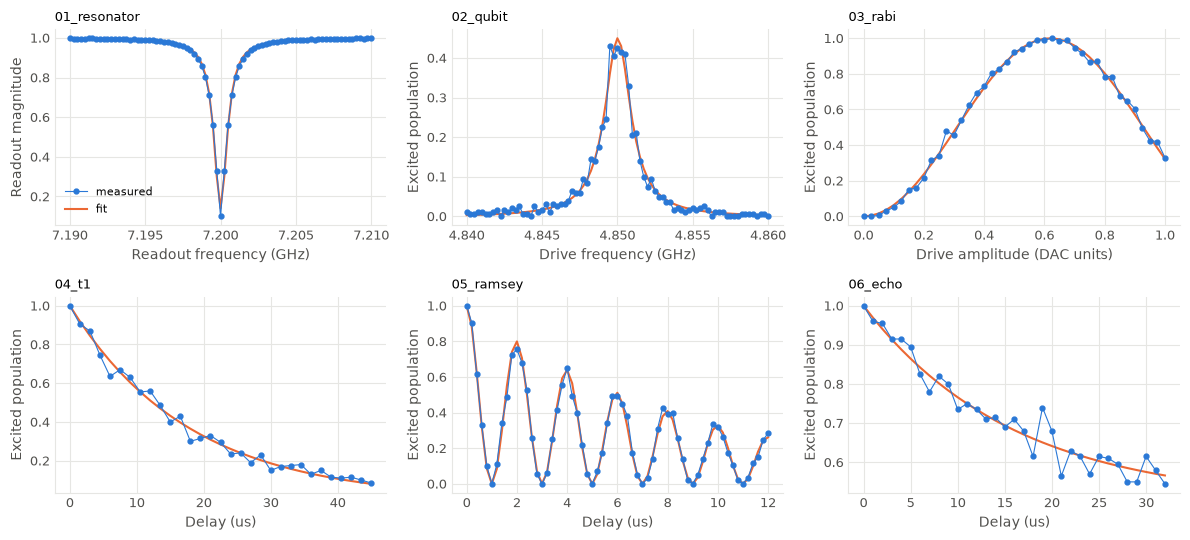

In [24]:
library = qp.WaveformLibrary()
library.set("pi", PI, element="q", idx=0, kind="drive")  # exactly what steps 4 to 6 played
library.set("x90", X90, element="q", idx=0, kind="drive")
library.set("readout", IQPair(Square(0.2, 2000), Square(0.0, 2000)), element="q", kind="readout")
library.set("weights", IQPair(Square(1.0, 2000), Square(1.0, 2000)))
library.save(OUT / "calibration.wfl")

print(f"{'quantity':<18}{'measured':>12}{'true':>12}{'error':>9}")
for name, (measured, truth) in CAL.items():
    print(f"{name:<18}{measured:>12.4f}{truth:>12.4f}{100 * abs(measured - truth) / abs(truth):>8.1f}%")
print(f"\nartifacts in {OUT}:")
print(" ", sorted(p.name for p in OUT.iterdir()))

fig, axes = plt.subplots(2, 3, figsize=(12, 5.5))
for ax, name in zip(axes.ravel(), TRACES, strict=True):
    draw(name, target=ax)
    ax.set_title(name, loc="left", fontsize=9)
axes[0, 0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## Recap

- Three extension seams cover new vocabulary: a `Waveform`, a `SweepSource`, and a vendor `Operation` behind a `VendorNamespace`. Each is a class plus a registration call, and each gets serialization, validation, and a capability token with no change to the core. A fourth, `register_vendor_block`, does the same for a vendor's own control flow, and a fifth, `register_profile`, publishes the token bundle a rack reaches by name.
- The token makes an extension safe. A rack that lacks it refuses the program with a named diagnostic and a path, before anything reaches an instrument, and the file stays legal QProgram everywhere else.
- Entry points make a `.qp` file self-describing. The `require` line names the vendor, and `loads()` imports the extension that claims it.
- The `.qp` file is the artifact you keep. It diffs, it reviews, and `python -m qprogram.lsp check` turns it into a CI job.
- The capstone recovered f_r, f01, the pi amplitude, T1, T2\*, the detuning, and T2 from simulated data, wrote a file per step, drew every panel through the result that produced it, and put the fitted pulses in a `.wfl` library.

## Next

The published documentation at qilimanjaro-tech.github.io/qprogram carries the normative material in its Reference section, `docs/reference/qp-format.md` covers the text format, and `src/qprogram/grammar/qp.lark` is the machine-readable grammar. `docs/developer/vendor-extensions.md` walks a vendor package end to end, and `qprogram-qdac` is the smallest complete one worth copying.

One idea to carry forward. The program, the plan, the result, and the calibration are all data, and everything this tutorial did followed from that. A program you can serialize is a program you can diff, review, check in CI, and hand to a different machine. A plan you can print is a performance question you can answer before you spend fridge time on it. A result that carries its own coordinates draws itself and puts a fit on the right axis. A calibration in a file is a number with a provenance rather than a literal somebody remembers typing.